# 📊 Customer Retention & Churn Analysis

# Future Interns – Data Science & Analytics Task 2

Objective:
Analyze customer behavior, identify churn patterns and retention drivers,
understand customer lifetime patterns, and provide actionable business
recommendations to reduce customer churn.

Tools Used:
Python, Pandas, NumPy, Matplotlib, Seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].dtype)

float64


In [12]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
TotalCharges,11


In [13]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Missing TotalCharges: 0


In [14]:
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (7043, 21)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
df["Churn_Encoded"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

df[["Churn", "Churn_Encoded"]].head()

,Churn,Churn_Encoded
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [19]:
total_customers = len(df)
churned_customers = df["Churn_Encoded"].sum()
retained_customers = total_customers - churned_customers

churn_rate = (churned_customers / total_customers) * 100
retention_rate = 100 - churn_rate

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:{:.2f}%".format(churn_rate))
print("Retention Rate:{:.2f}%".format(retention_rate))

Total Customers: 7043
Churned Customers: 1869
Retained Customers: 5174
Churn Rate:26.54%
Retention Rate:73.46%


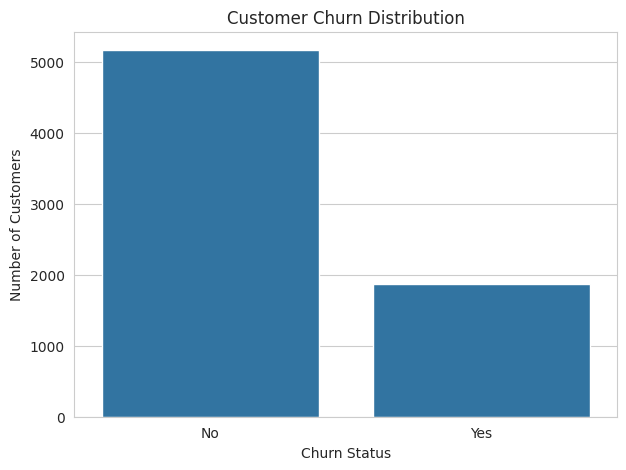

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


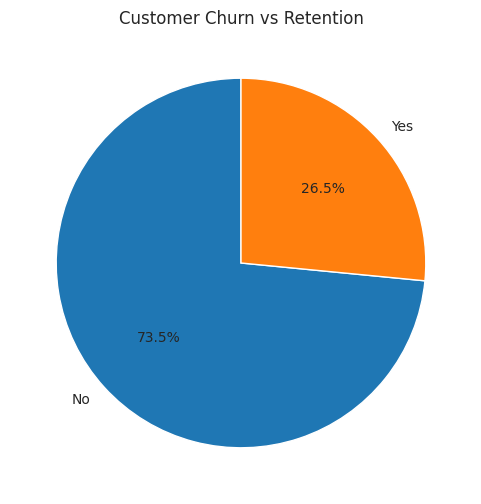

In [21]:
churn_distribution = df["Churn"].value_counts(normalize=True) * 100

print(churn_distribution)
plt.figure(figsize=(6, 6))

plt.pie(
    churn_distribution,
    labels=churn_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn vs Retention")

plt.show()

In [22]:
def churn_by_category(column):
    result = (
        df.groupby(column)["Churn_Encoded"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    result.columns = [
        column,
        "Total Customers",
        "Churned Customers",
        "Churn Rate"
    ]

    result["Churn Rate"] = result["Churn Rate"] * 100

    return result.sort_values("Churn Rate", ascending=False)

In [23]:
contract_churn = churn_by_category("Contract")

contract_churn

,Contract,Total Customers,Churned Customers,Churn Rate
0,Month-to-month,3875,1655,42.709677
1,One year,1473,166,11.269518
2,Two year,1695,48,2.831858


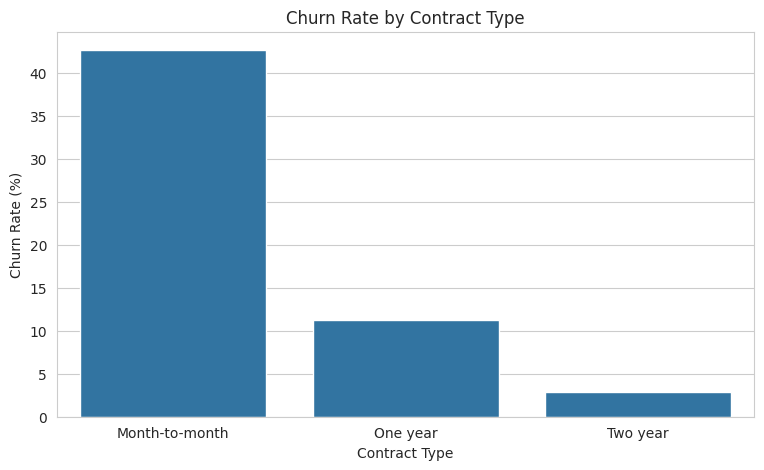

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=contract_churn,
    x="Contract",
    y="Churn Rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

In [25]:
df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 60, np.inf],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-60 Months",
        "60+ Months"
    ]
)

df["Tenure_Group"].value_counts().sort_index()

,count
Tenure_Group,
0-12 Months,2186
13-24 Months,1024
25-48 Months,1594
49-60 Months,832
60+ Months,1407


In [26]:
tenure_churn = churn_by_category("Tenure_Group")

tenure_churn

/tmp/ipykernel_2359/217236976.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(column)["Churn_Encoded"]


,Tenure_Group,Total Customers,Churned Customers,Churn Rate
0,0-12 Months,2186,1037,47.438243
1,13-24 Months,1024,294,28.710938
2,25-48 Months,1594,325,20.388959
3,49-60 Months,832,120,14.423077
4,60+ Months,1407,93,6.609808


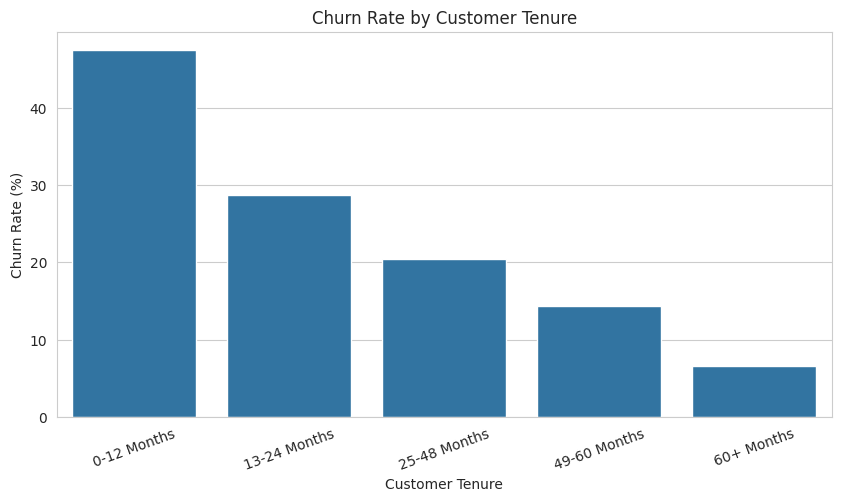

In [27]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=tenure_churn,
    x="Tenure_Group",
    y="Churn Rate"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.show()

In [28]:
internet_churn = churn_by_category("InternetService")

internet_churn

,InternetService,Total Customers,Churned Customers,Churn Rate
1,Fiber optic,3096,1297,41.892765
0,DSL,2421,459,18.959108
2,No,1526,113,7.404980


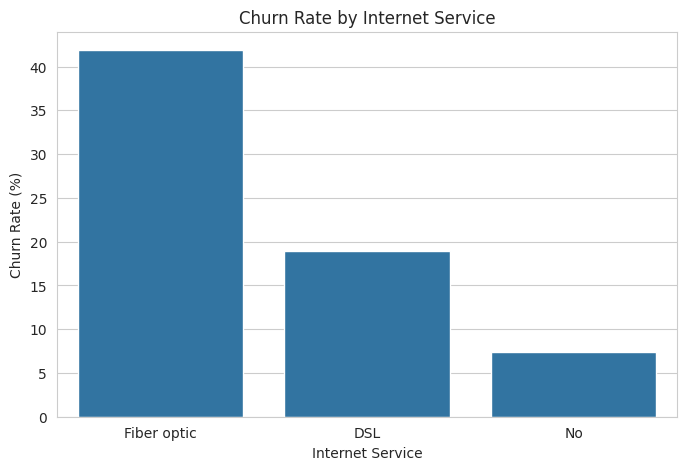

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=internet_churn,
    x="InternetService",
    y="Churn Rate"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

In [30]:
payment_churn = churn_by_category("PaymentMethod")

payment_churn

,PaymentMethod,Total Customers,Churned Customers,Churn Rate
2,Electronic check,2365,1071,45.285412
3,Mailed check,1612,308,19.106700
0,Bank transfer (automatic),1544,258,16.709845
1,Credit card (automatic),1522,232,15.243101


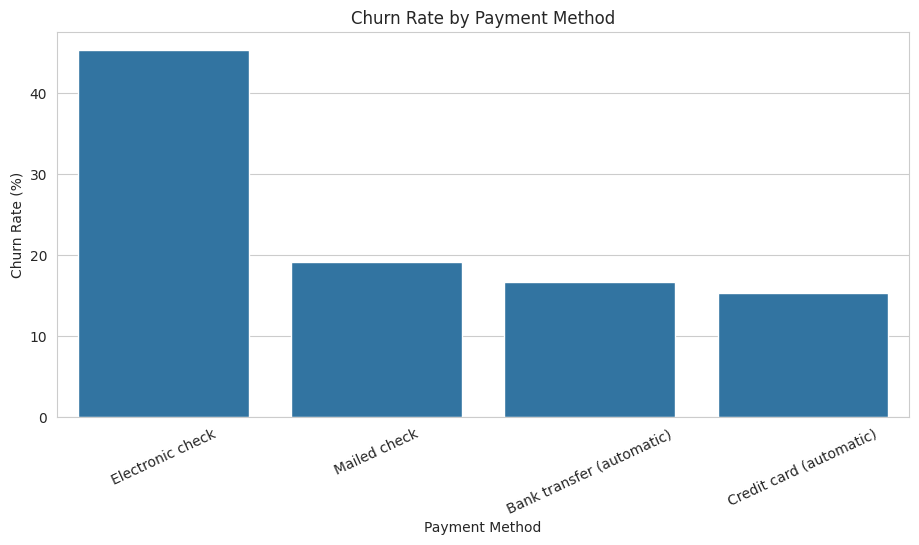

In [31]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="Churn Rate"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=25)

plt.show()

In [32]:
support_churn = churn_by_category("TechSupport")

support_churn

,TechSupport,Total Customers,Churned Customers,Churn Rate
0,No,3473,1446,41.635474
2,Yes,2044,310,15.166341
1,No internet service,1526,113,7.404980


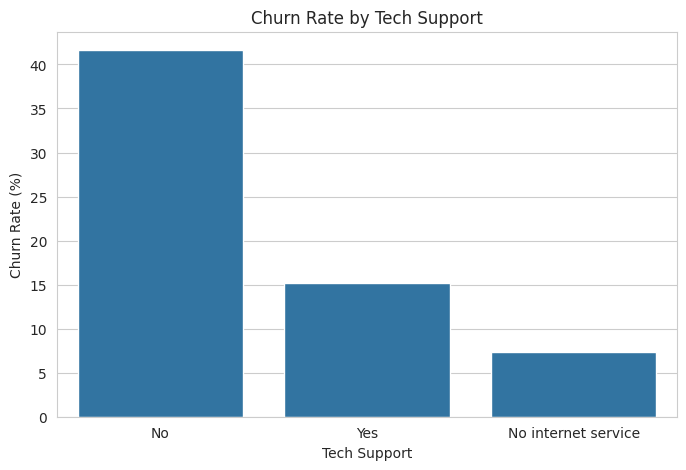

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=support_churn,
    x="TechSupport",
    y="Churn Rate"
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

plt.show()

In [34]:
security_churn = churn_by_category("OnlineSecurity")

security_churn

,OnlineSecurity,Total Customers,Churned Customers,Churn Rate
0,No,3498,1461,41.766724
2,Yes,2019,295,14.611194
1,No internet service,1526,113,7.404980


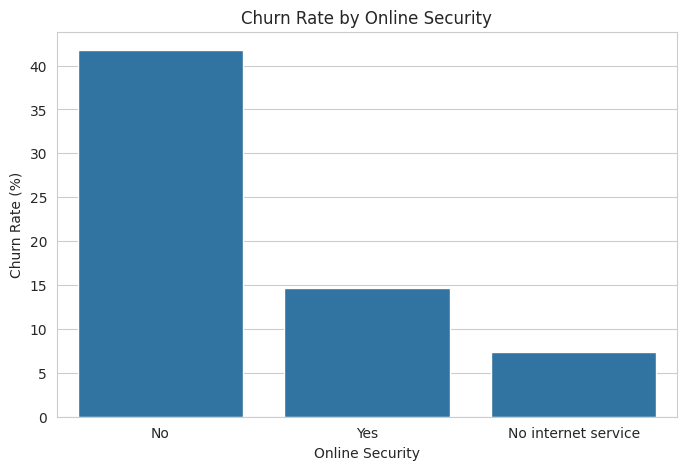

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=security_churn,
    x="OnlineSecurity",
    y="Churn Rate"
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

plt.show()

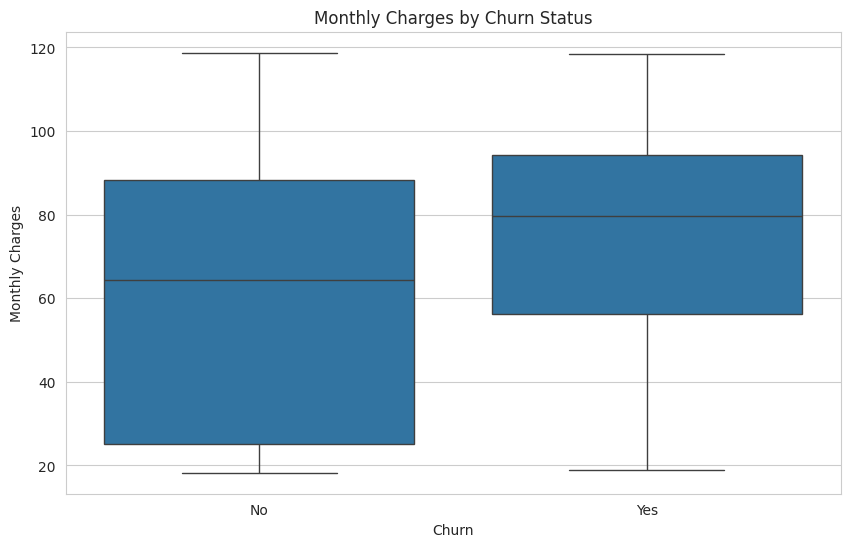

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

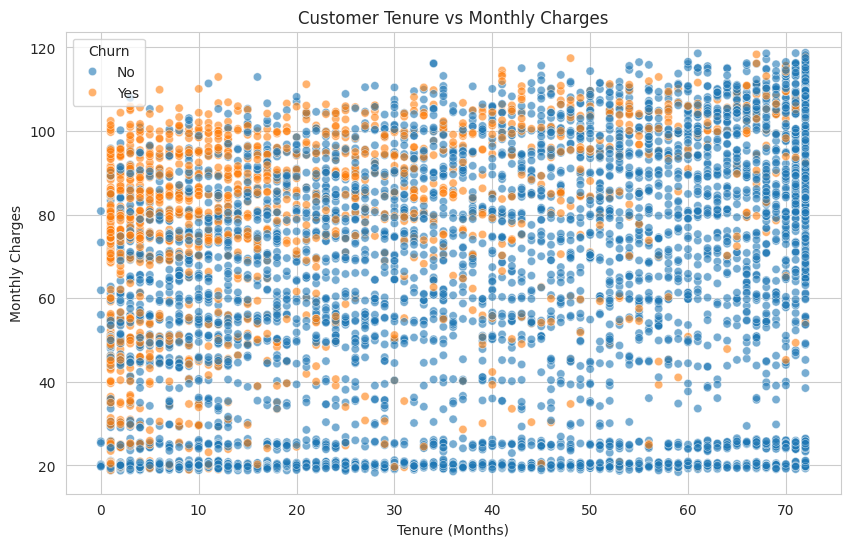

In [37]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Customer Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.show()

In [38]:
senior_churn = churn_by_category("SeniorCitizen")

senior_churn

,SeniorCitizen,Total Customers,Churned Customers,Churn Rate
1,1,1142,476,41.681261
0,0,5901,1393,23.606168


In [39]:
senior_churn["Customer Type"] = senior_churn["SeniorCitizen"].map({
    0: "Non-Senior Citizen",
    1: "Senior Citizen"
})

senior_churn

,SeniorCitizen,Total Customers,Churned Customers,Churn Rate,Customer Type
1,1,1142,476,41.681261,Senior Citizen
0,0,5901,1393,23.606168,Non-Senior Citizen


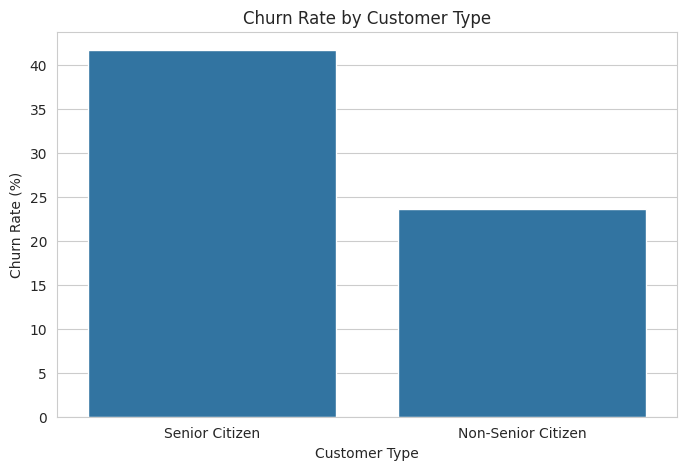

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=senior_churn,
    x="Customer Type",
    y="Churn Rate"
)

plt.title("Churn Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Churn Rate (%)")

plt.show()

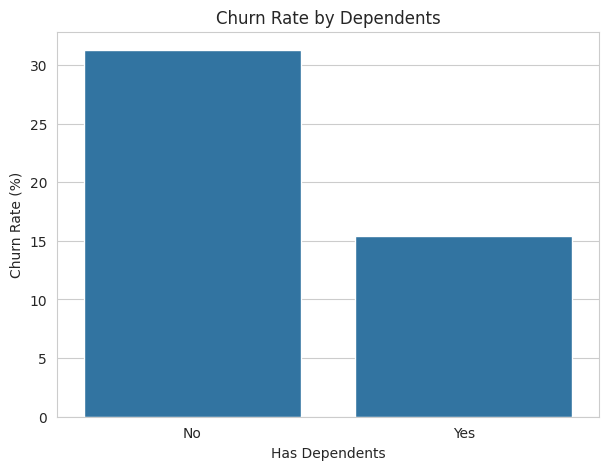

In [43]:
dependents_churn = churn_by_category("Dependents")

dependents_churn

plt.figure(figsize=(7, 5))

sns.barplot(
    data=dependents_churn,
    x="Dependents",
    y="Churn Rate"
)

plt.title("Churn Rate by Dependents")
plt.xlabel("Has Dependents")
plt.ylabel("Churn Rate (%)")

plt.show()

In [44]:
average_tenure = df["tenure"].mean()

print("Average Customer Tenure: {:.2f} months".format(average_tenure))

Average Customer Tenure: 32.37 months


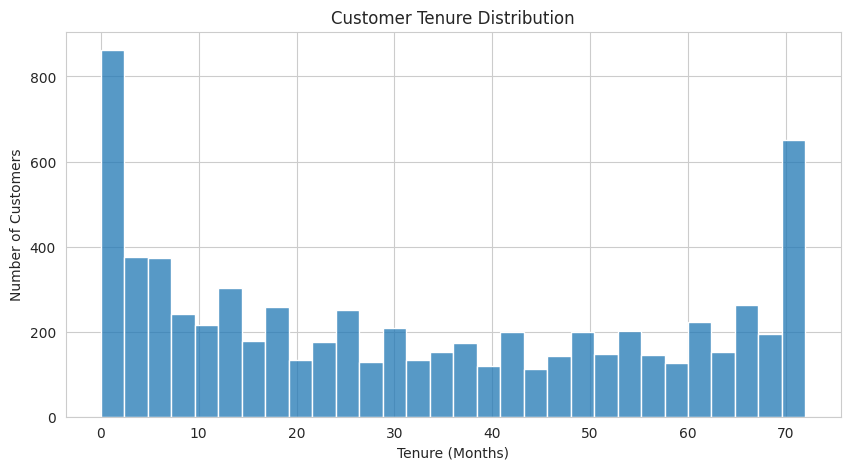

In [45]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [46]:
tenure_retention = df.groupby("Tenure_Group")["Churn_Encoded"].agg(
    ["count", "mean"]
).reset_index()

tenure_retention.columns = [
    "Tenure Group",
    "Total Customers",
    "Churn Rate"
]

tenure_retention["Churn Rate"] *= 100

tenure_retention["Retention Rate"] = (
    100 - tenure_retention["Churn Rate"]
)

tenure_retention

/tmp/ipykernel_2359/4132383656.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_retention = df.groupby("Tenure_Group")["Churn_Encoded"].agg(


,Tenure Group,Total Customers,Churn Rate,Retention Rate
0,0-12 Months,2186,47.438243,52.561757
1,13-24 Months,1024,28.710938,71.289062
2,25-48 Months,1594,20.388959,79.611041
3,49-60 Months,832,14.423077,85.576923
4,60+ Months,1407,6.609808,93.390192


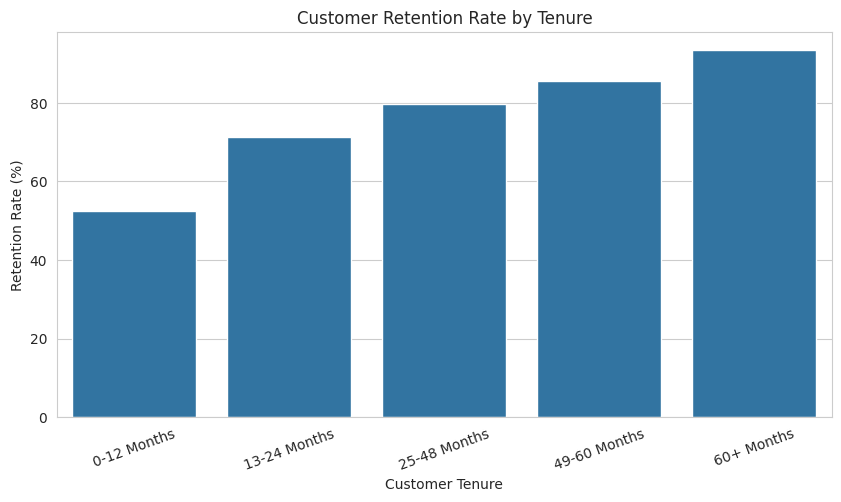

In [47]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=tenure_retention,
    x="Tenure Group",
    y="Retention Rate"
)

plt.title("Customer Retention Rate by Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Retention Rate (%)")

plt.xticks(rotation=20)

plt.show()

In [51]:
# Churn rate by contract and tenure group

contract_tenure_churn = (
    df.groupby(["Contract", "Tenure_Group"], observed=True)["Churn_Encoded"]
    .mean()
    .reset_index()
)

# Convert churn rate to percentage
contract_tenure_churn["Churn_Encoded"] *= 100

contract_tenure_churn.head(20)

,Contract,Tenure_Group,Churn_Encoded
0,Month-to-month,0-12 Months,51.354062
1,Month-to-month,13-24 Months,37.720488
2,Month-to-month,25-48 Months,32.917706
3,Month-to-month,49-60 Months,27.777778
4,Month-to-month,60+ Months,22.222222
5,One year,0-12 Months,10.483871
6,One year,13-24 Months,8.121827
7,One year,25-48 Months,10.617761
8,One year,49-60 Months,13.707165
9,One year,60+ Months,12.140575


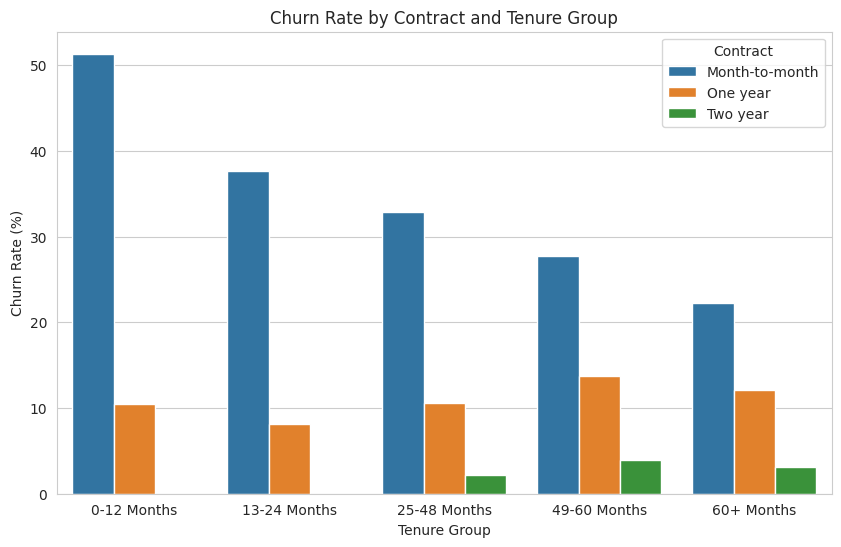

In [52]:
# Visualize churn rate by contract and tenure group

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=contract_tenure_churn,
    x="Tenure_Group",
    y="Churn_Encoded",
    hue="Contract"
)

plt.title("Churn Rate by Contract and Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Contract")
plt.show()

In [53]:
contract_churn = (
    df.groupby("Contract", observed=True)["Churn_Encoded"]
    .mean()
    .reset_index()
)

contract_churn["Churn_Encoded"] *= 100

contract_churn

,Contract,Churn_Encoded
0,Month-to-month,42.709677
1,One year,11.269518
2,Two year,2.831858


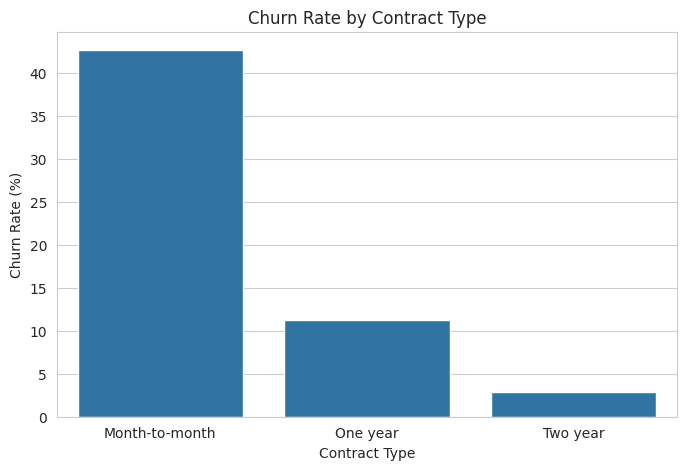

In [54]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn,
    x="Contract",
    y="Churn_Encoded"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()


In [55]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn_Encoded"]
    .mean()
    .reset_index()
)

payment_churn["Churn_Encoded"] *= 100

payment_churn

,PaymentMethod,Churn_Encoded
0,Bank transfer (automatic),16.709845
1,Credit card (automatic),15.243101
2,Electronic check,45.285412
3,Mailed check,19.106700


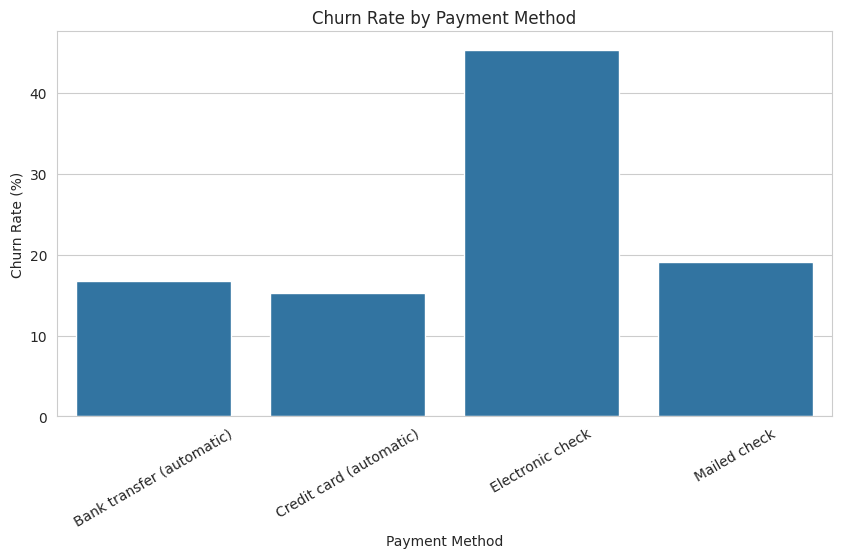

In [56]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_churn,
    x="PaymentMethod",
    y="Churn_Encoded"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [58]:
# Calculate churn rate by Internet Service

internet_churn = (
    df.groupby("InternetService", observed=True)["Churn_Encoded"]
    .mean()
    .reset_index(name="Churn_Rate")
)

# Convert to percentage
internet_churn["Churn_Rate"] *= 100

internet_churn

,InternetService,Churn_Rate
0,DSL,18.959108
1,Fiber optic,41.892765
2,No,7.404980


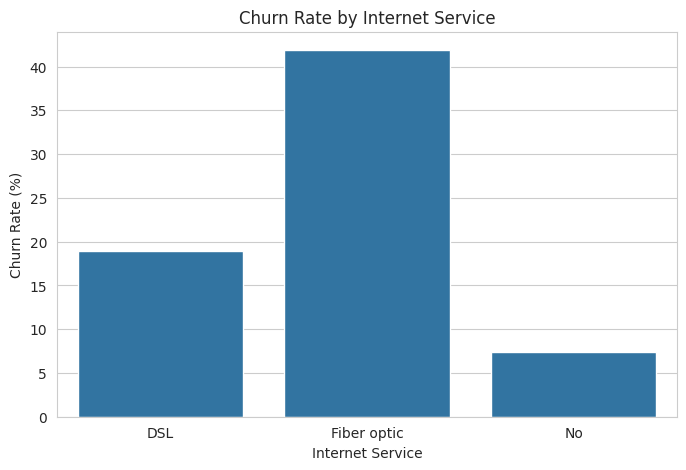

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=internet_churn,
    x="InternetService",
    y="Churn_Rate"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

In [60]:
# Calculate churn rate by Senior Citizen status

senior_churn = (
    df.groupby("SeniorCitizen")["Churn_Encoded"]
    .mean()
    .reset_index(name="Churn_Rate")
)

senior_churn["Churn_Rate"] *= 100

senior_churn

,SeniorCitizen,Churn_Rate
0,0,23.606168
1,1,41.681261


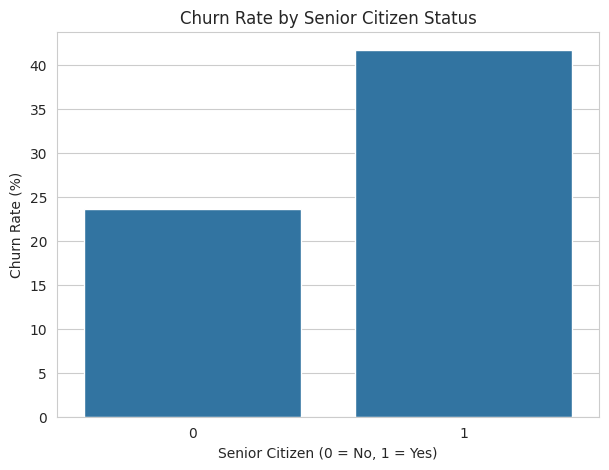

In [61]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=senior_churn,
    x="SeniorCitizen",
    y="Churn_Rate"
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.show()

In [62]:
# Calculate churn rate by Partner status

partner_churn = (
    df.groupby("Partner")["Churn_Encoded"]
    .mean()
    .reset_index(name="Churn_Rate")
)

partner_churn["Churn_Rate"] *= 100

partner_churn

,Partner,Churn_Rate
0,No,32.957979
1,Yes,19.664903


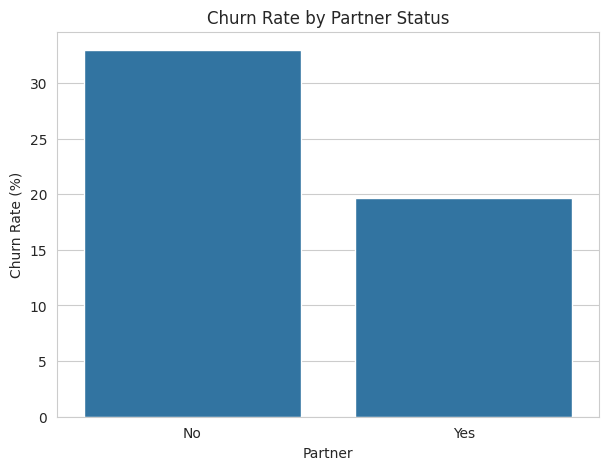

In [63]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=partner_churn,
    x="Partner",
    y="Churn_Rate"
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.show()

In [64]:
# Customer lifetime analysis

df["tenure"].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [65]:
# Average tenure of churned and retained customers

lifetime_churn = (
    df.groupby("Churn")["tenure"]
    .mean()
    .reset_index()
)

lifetime_churn

,Churn,tenure
0,No,37.569965
1,Yes,17.979133


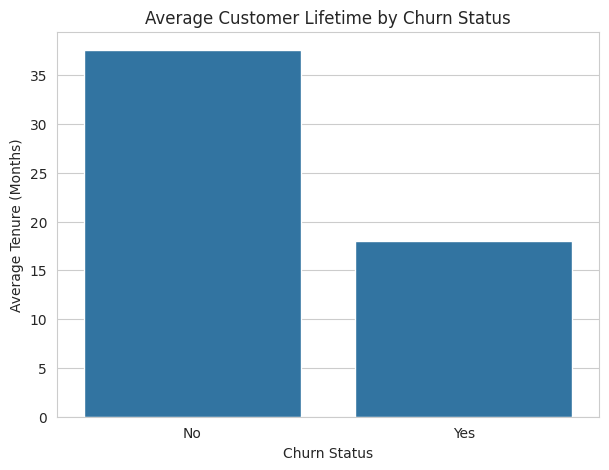

In [66]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=lifetime_churn,
    x="Churn",
    y="tenure"
)

plt.title("Average Customer Lifetime by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Tenure (Months)")
plt.show()

In [67]:
# Customer cohort analysis using tenure groups

cohort_analysis = (
    df.groupby("Tenure_Group", observed=True)
    .agg(
        Customers=("customerID", "count"),
        Churn_Rate=("Churn_Encoded", "mean")
    )
    .reset_index()
)

cohort_analysis["Churn_Rate"] *= 100

cohort_analysis

,Tenure_Group,Customers,Churn_Rate
0,0-12 Months,2186,47.438243
1,13-24 Months,1024,28.710938
2,25-48 Months,1594,20.388959
3,49-60 Months,832,14.423077
4,60+ Months,1407,6.609808


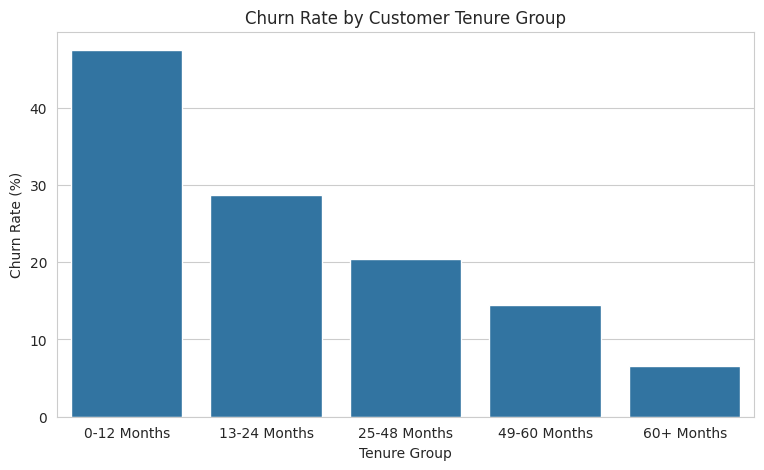

In [68]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=cohort_analysis,
    x="Tenure_Group",
    y="Churn_Rate"
)

plt.title("Churn Rate by Customer Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.show()

In [69]:
# Overall churn and retention rate

overall_churn = df["Churn_Encoded"].mean() * 100
overall_retention = 100 - overall_churn

print(f"Overall Churn Rate: {overall_churn:.2f}%")
print(f"Overall Retention Rate: {overall_retention:.2f}%")

Overall Churn Rate: 26.54%
Overall Retention Rate: 73.46%


In [70]:
# Key business insights

highest_churn_contract = contract_churn.loc[
    contract_churn["Churn_Encoded"].idxmax(), "Contract"
]

highest_churn_contract_rate = contract_churn["Churn_Encoded"].max()

print("KEY INSIGHTS")
print("-" * 50)

print(f"1. Overall churn rate is {overall_churn:.2f}%.")
print(f"2. Overall retention rate is {overall_retention:.2f}%.")
print(f"3. The contract type with the highest churn is '{highest_churn_contract}' "
      f"with a churn rate of {highest_churn_contract_rate:.2f}%.")
print("4. Customers with shorter tenure generally show higher churn.")
print("5. Longer-tenure customers are generally more likely to remain with the company.")

KEY INSIGHTS
--------------------------------------------------
1. Overall churn rate is 26.54%.
2. Overall retention rate is 73.46%.
3. The contract type with the highest churn is 'Month-to-month' with a churn rate of 42.71%.
4. Customers with shorter tenure generally show higher churn.
5. Longer-tenure customers are generally more likely to remain with the company.


In [71]:
# Recommendations to reduce customer churn

print("RECOMMENDATIONS")
print("-" * 50)

print("1. Provide incentives to move customers from short-term to long-term contracts.")
print("2. Focus retention campaigns on new and low-tenure customers.")
print("3. Offer personalized plans and discounts to customers showing churn risk.")
print("4. Improve customer support and service experience.")
print("5. Regularly monitor churn rates across customer segments.")

RECOMMENDATIONS
--------------------------------------------------
1. Provide incentives to move customers from short-term to long-term contracts.
2. Focus retention campaigns on new and low-tenure customers.
3. Offer personalized plans and discounts to customers showing churn risk.
4. Improve customer support and service experience.
5. Regularly monitor churn rates across customer segments.


In [72]:
# Save cleaned dataset for Power BI

df.to_csv("Telco_Customer_Churn_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [73]:
from google.colab import files

files.download("Telco_Customer_Churn_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
# Final summary of important churn metrics

summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Overall Churn Rate (%)",
        "Overall Retention Rate (%)",
        "Average Tenure (Months)"
    ],
    "Value": [
        len(df),
        df["Churn_Encoded"].sum(),
        len(df) - df["Churn_Encoded"].sum(),
        overall_churn,
        overall_retention,
        df["tenure"].mean()
    ]
})

summary

,Metric,Value
0,Total Customers,7043.000000
1,Churned Customers,1869.000000
2,Retained Customers,5174.000000
3,Overall Churn Rate (%),26.536987
4,Overall Retention Rate (%),73.463013
5,Average Tenure (Months),32.371149


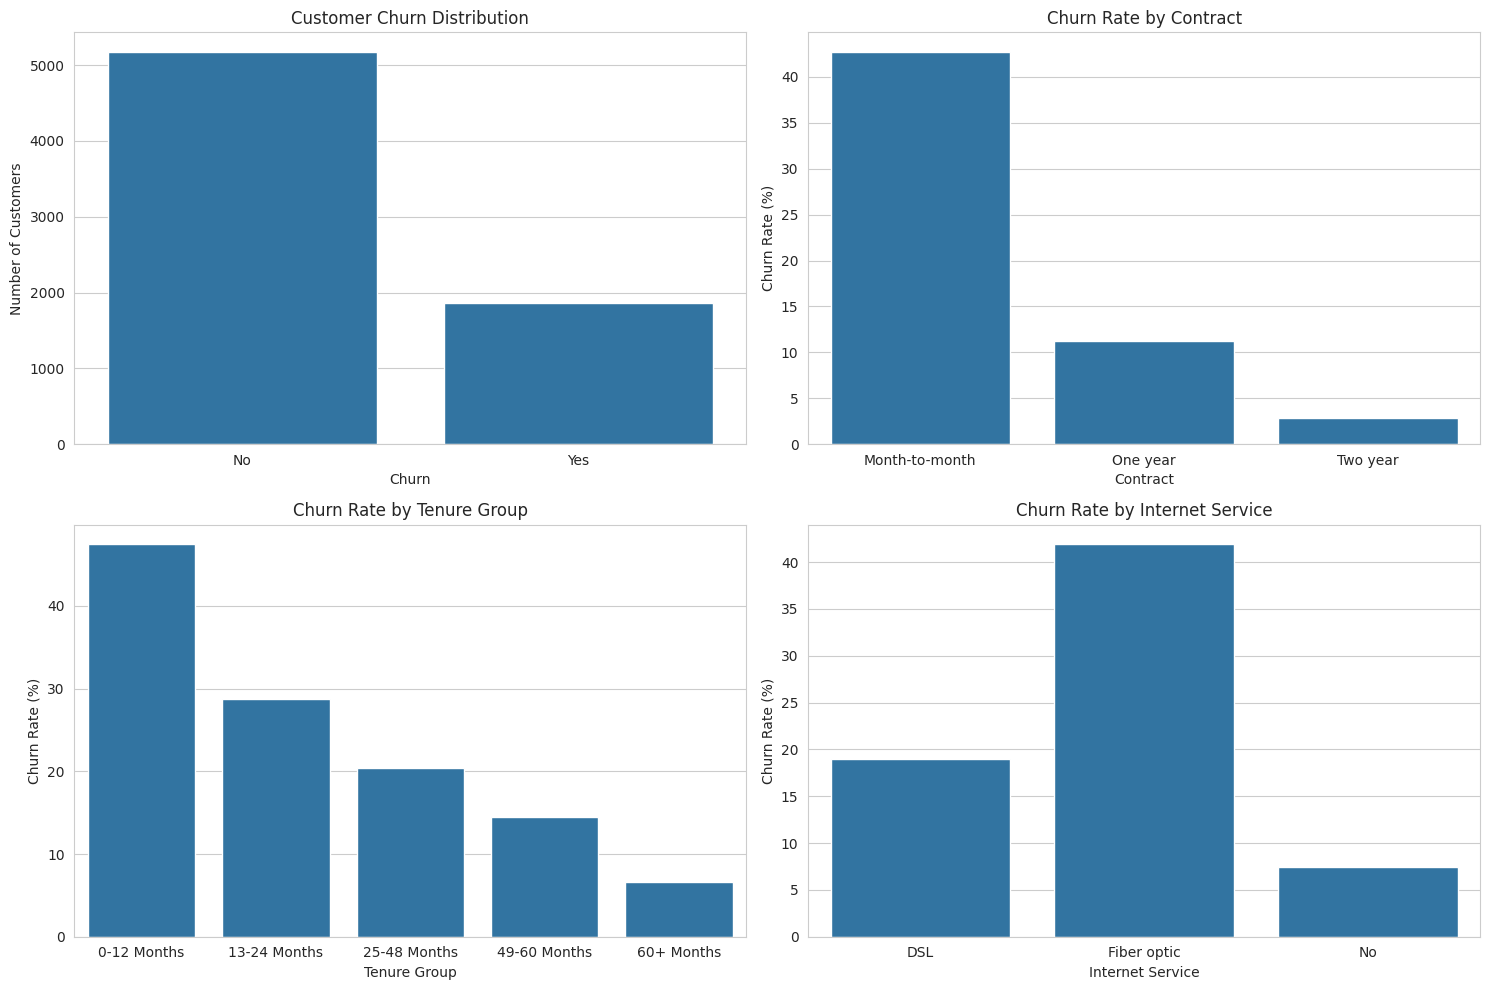

In [75]:
# Create a simple final churn analysis dashboard

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Churn Distribution
sns.countplot(data=df, x="Churn", ax=axes[0, 0])
axes[0, 0].set_title("Customer Churn Distribution")
axes[0, 0].set_xlabel("Churn")
axes[0, 0].set_ylabel("Number of Customers")

# 2. Churn by Contract
sns.barplot(
    data=contract_churn,
    x="Contract",
    y="Churn_Encoded",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Churn Rate by Contract")
axes[0, 1].set_xlabel("Contract")
axes[0, 1].set_ylabel("Churn Rate (%)")

# 3. Churn by Tenure Group
sns.barplot(
    data=cohort_analysis,
    x="Tenure_Group",
    y="Churn_Rate",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Churn Rate by Tenure Group")
axes[1, 0].set_xlabel("Tenure Group")
axes[1, 0].set_ylabel("Churn Rate (%)")

# 4. Churn by Internet Service
sns.barplot(
    data=internet_churn,
    x="InternetService",
    y="Churn_Rate",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Churn Rate by Internet Service")
axes[1, 1].set_xlabel("Internet Service")
axes[1, 1].set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [76]:
# Final business conclusion

print("=" * 60)
print("CUSTOMER RETENTION & CHURN ANALYSIS - FINAL CONCLUSION")
print("=" * 60)

print(f"\nOverall Churn Rate: {overall_churn:.2f}%")
print(f"Overall Retention Rate: {overall_retention:.2f}%")
print(f"Average Customer Tenure: {df['tenure'].mean():.2f} months")

print("\nKEY FINDINGS:")
print("• Churn is an important customer retention challenge.")
print("• Customers with shorter tenure are more likely to churn.")
print("• Contract type has a noticeable impact on customer churn.")
print("• Longer-tenure customers generally show better retention.")
print("• Internet service type also shows differences in churn behavior.")

print("\nRECOMMENDATIONS:")
print("• Target new customers with early-stage retention campaigns.")
print("• Encourage customers to choose longer-term contracts.")
print("• Provide personalized offers to high-risk customers.")
print("• Improve customer service and overall customer experience.")
print("• Monitor churn regularly to identify changing customer behavior.")

print("\nCONCLUSION:")
print("The analysis shows that customer tenure and contract type are")
print("important factors related to churn. The business should focus")
print("on retaining new customers and encouraging long-term contracts.")

CUSTOMER RETENTION & CHURN ANALYSIS - FINAL CONCLUSION

Overall Churn Rate: 26.54%
Overall Retention Rate: 73.46%
Average Customer Tenure: 32.37 months

KEY FINDINGS:
• Churn is an important customer retention challenge.
• Customers with shorter tenure are more likely to churn.
• Contract type has a noticeable impact on customer churn.
• Longer-tenure customers generally show better retention.
• Internet service type also shows differences in churn behavior.

RECOMMENDATIONS:
• Target new customers with early-stage retention campaigns.
• Encourage customers to choose longer-term contracts.
• Provide personalized offers to high-risk customers.
• Improve customer service and overall customer experience.
• Monitor churn regularly to identify changing customer behavior.

CONCLUSION:
The analysis shows that customer tenure and contract type are
important factors related to churn. The business should focus
on retaining new customers and encouraging long-term contracts.


In [77]:
# Save important analysis tables

with pd.ExcelWriter("Churn_Analysis_Report.xlsx") as writer:
    summary.to_excel(writer, sheet_name="Summary", index=False)
    contract_churn.to_excel(writer, sheet_name="Contract_Churn", index=False)
    cohort_analysis.to_excel(writer, sheet_name="Tenure_Cohort", index=False)
    internet_churn.to_excel(writer, sheet_name="Internet_Churn", index=False)
    lifetime_churn.to_excel(writer, sheet_name="Customer_Lifetime", index=False)

print("Churn analysis report created successfully.")

Churn analysis report created successfully.


In [78]:
from google.colab import files

files.download("Churn_Analysis_Report.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>